# Liver Disease Model Training
### ILPD Dataset — Full Pipeline: Correlation → Feature Selection → Split → Scale → Train → Evaluate

##  Imports & Load  Data

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("Indian Liver Patient Dataset (ILPD).csv", header=None)
data.columns = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Protiens",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
    "Output",
]

data.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Output
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
print("Number of rows and columns:")
print(data.shape)

print("\nColumn names:")
print(data.columns)

print("\nDataset info:")
data.info()

Number of rows and columns:
(583, 11)

Column names:
Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Output'],
      dtype='str')

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin 

In [ ]:
# Convert target: 1 = Liver Disease, 2 = No Disease  →  binary 1 / 0
data['Output'] = data['Output'].map({1: 1, 2: 0})
data.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Output
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


### Target Variable

The target variable in this dataset is **Output**.

Values:
1 → Liver Disease Patient  
0 → Non Liver Disease Patient

In [ ]:
print(data['Output'].value_counts().rename({1: 'Liver Disease', 0: 'No Disease'}))
data.head()

Output
Liver Disease    416
No Disease       167
Name: count, dtype: int64


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Output
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
data.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Output                        0
dtype: int64

In [ ]:
data = data.fillna(data.mean(numeric_only=True))

data.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Output                        0
dtype: int64

In [ ]:
data.dtypes

Age                             int64
Gender                            str
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Protiens                float64
Albumin                       float64
Albumin_and_Globulin_Ratio    float64
Output                          int64
dtype: object

**Converting String Columns to Numeric**
Values:
1 → Male Patient  
0 → Female Patient

In [ ]:
label = LabelEncoder()
data["Gender"] = label.fit_transform(data["Gender"])

data.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Output
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [ ]:
numerical_features = data.select_dtypes(include=['int64','float64']).columns
categorical_features = data.select_dtypes(include=['object']).columns

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Output'],
      dtype='str')

Categorical features:
Index([], dtype='str')


**Feature Description**

| **Feature Name**          | **Description**                                | **Type**    |
| ------------------------- | ---------------------------------------------- | ----------- |
| Age                       | Age of the patient (in years)                  | Numerical   |
| Gender                    | Gender of the patient (Male / Female)          | Categorical |
| Total_Bilirubin           | Total bilirubin level in blood (mg/dL)         | Numerical   |
| Direct_Bilirubin          | Direct (conjugated) bilirubin (mg/dL)          | Numerical   |
| ALP                       | Alkaline Phosphotase enzyme level              | Numerical   |
| ALT                       | Alamine Aminotransferase (SGPT) enzyme level   | Numerical   |
| AST                       | Aspartate Aminotransferase (SGOT) enzyme level | Numerical   |
| Total_Proteins            | Total protein level in blood                   | Numerical   |
| Albumin                   | Albumin protein level (produced by liver)      | Numerical   |
| A_G_Ratio                 | Albumin and Globulin ratio                     | Numerical   |
| Dataset (Target Variable) | 1 = Liver Disease, 2 = No Liver Disease        | Categorical |



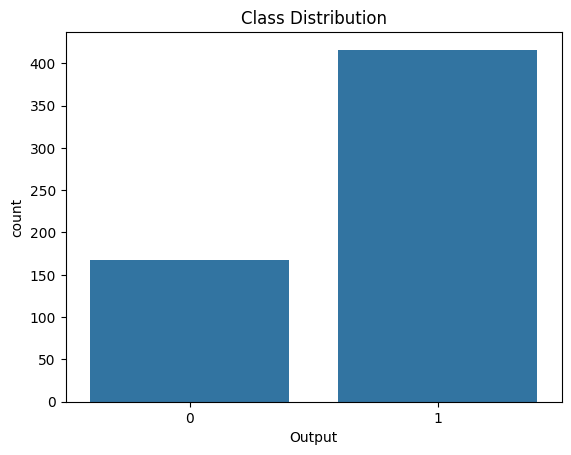

In [ ]:
sns.countplot(x="Output", data=data)
plt.title("Class Distribution")
plt.show()

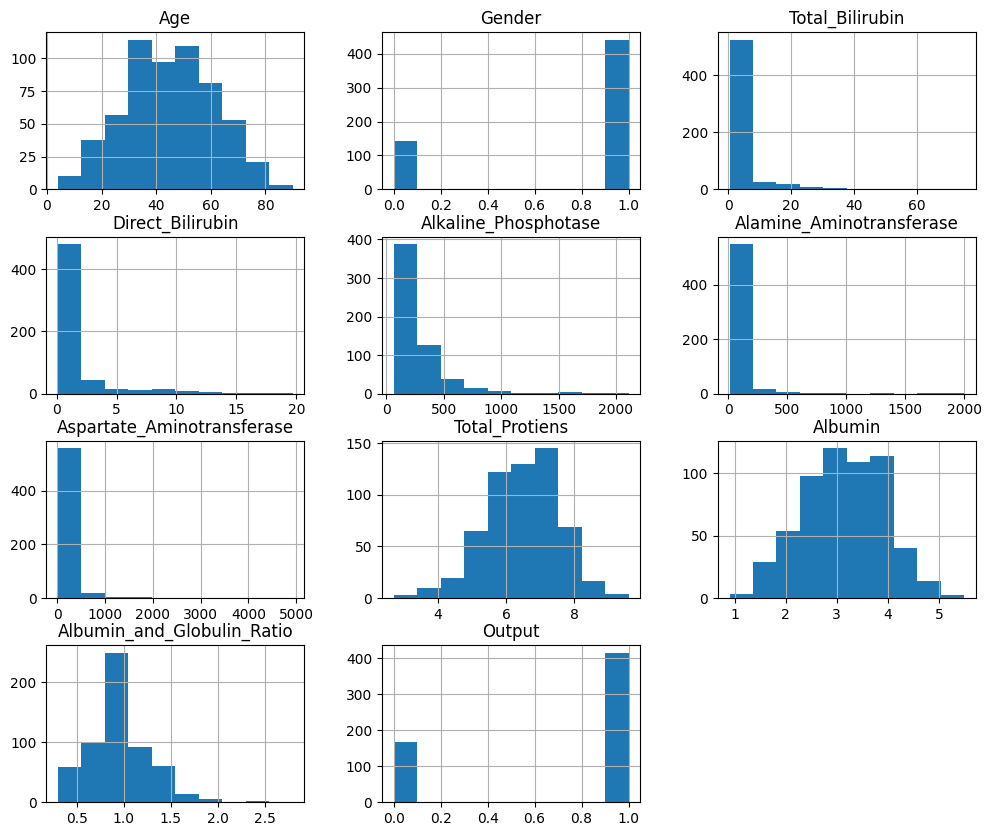

In [ ]:
data.hist(figsize=(12,10))
plt.show()

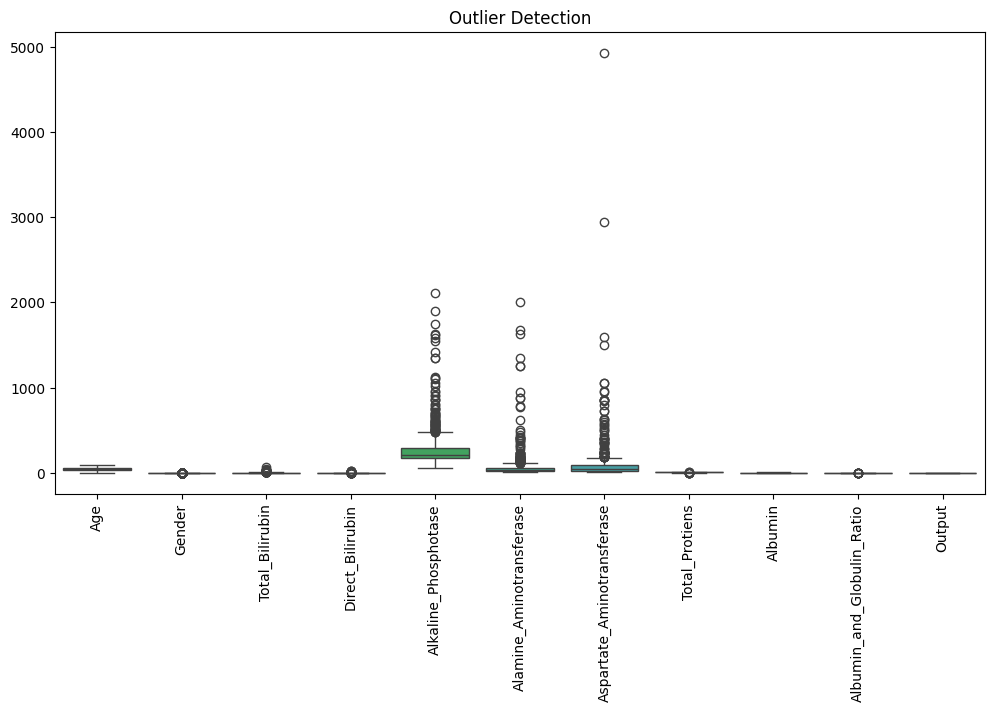

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

In [ ]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(data)

data = pd.DataFrame(scaled, columns=data.columns)

data.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Output
0,0.709302,0.0,0.004021,0.000000,0.060576,0.003015,0.001626,0.594203,0.521739,0.240,1.0
1,0.674419,1.0,0.140751,0.275510,0.310699,0.027136,0.018296,0.695652,0.500000,0.176,1.0
2,0.674419,1.0,0.092493,0.204082,0.208598,0.025126,0.011791,0.623188,0.521739,0.236,1.0
3,0.627907,1.0,0.008043,0.015306,0.058134,0.002010,0.002033,0.594203,0.543478,0.280,1.0
4,0.790698,1.0,0.046917,0.096939,0.064485,0.008543,0.009961,0.666667,0.326087,0.040,1.0


In [ ]:
data.to_csv("processed_liver_data.csv", index=False)

print("Processed data saved successfully!")

Processed data saved successfully!


## Correlation Analysis
> Detect multicollinearity | Decide if feature removal is needed (threshold ~0.85–0.90)

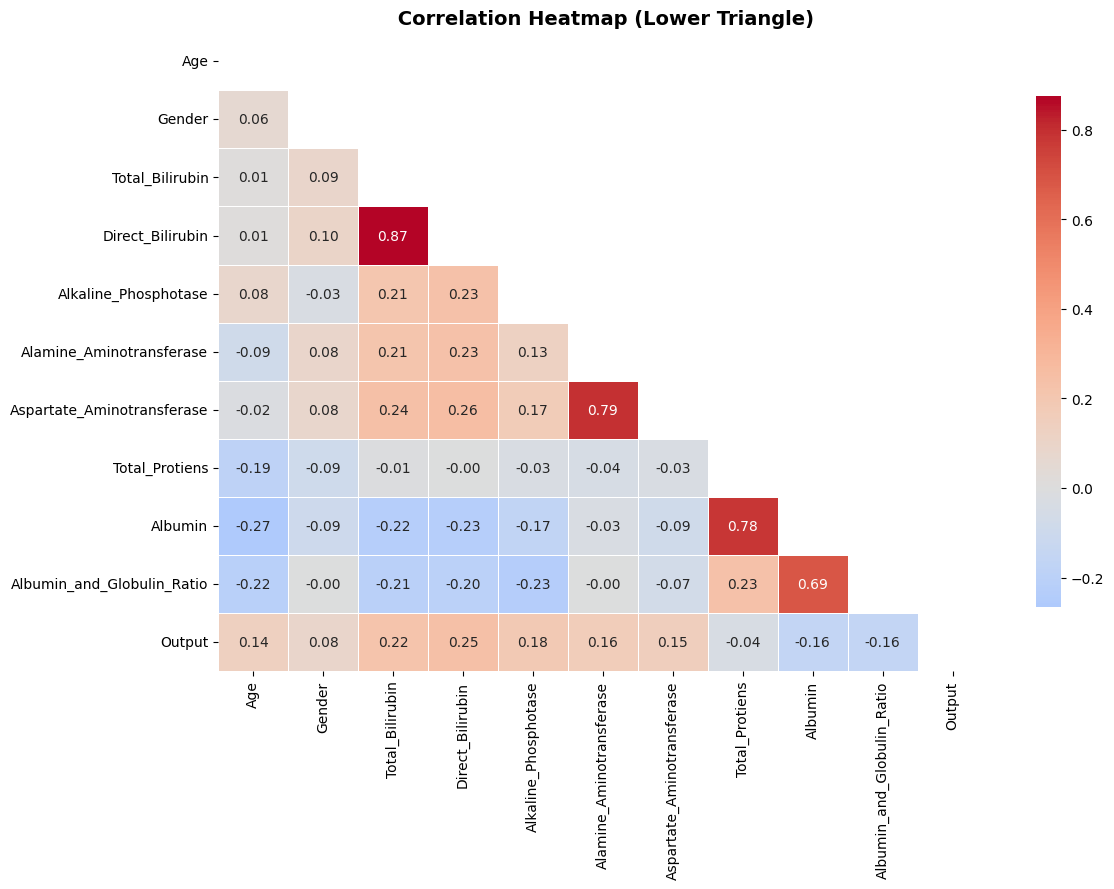

In [ ]:
corr_matrix = data.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # show lower triangle only
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title(' Correlation Heatmap (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
#  Identify highly correlated pairs 
THRESHOLD = 0.85
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= THRESHOLD:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(val, 3)
            ))

print(f'Highly correlated feature pairs (|r| >= {THRESHOLD}):')
if high_corr_pairs:
    for a, b, v in high_corr_pairs:
        print(f'   {a}  ↔  {b}  →  r = {v}')
else:
    print('   None found.')

Highly correlated feature pairs (|r| >= 0.85):
   Total_Bilirubin  ↔  Direct_Bilirubin  →  r = 0.875


## Feature Selection Strategy
> Create **Full Dataset** (all features) AND **Reduced Dataset** (drop one from each highly-correlated pair)

In [ ]:
# ── Automatically determine which column to drop from each correlated pair ─
# Rule: drop the feature that is LESS correlated with the target variable

target_corr = data.corr()['Output'].abs()
to_drop = set()

for a, b, _ in high_corr_pairs:
    drop_col = a if target_corr[a] <= target_corr[b] else b
    to_drop.add(drop_col)

print('Features selected to DROP from reduced dataset:', to_drop if to_drop else 'None')

Features selected to DROP from reduced dataset: {'Total_Bilirubin'}


In [ ]:
# Build two X datasets 
y = data['Output']
X_full = data.drop(columns=['Output'])
X_reduced = data.drop(columns=['Output'] + list(to_drop))

print(f'\nFull dataset    features : {X_full.shape[1]} → {list(X_full.columns)}')
print(f'Reduced dataset features : {X_reduced.shape[1]} → {list(X_reduced.columns)}')


Full dataset    features : 10 → ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']
Reduced dataset features : 9 → ['Age', 'Gender', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio']



## Handle Class Imbalance + Train-Test Split
> Class 1 (Liver Disease): 416 samples vs Class 0: 167 samples — needs balancing

In [ ]:

from sklearn.model_selection import  cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.utils import resample

In [ ]:
# Split → Oversample minority class in training set only.
def split_and_balance(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # Oversample minority class (No Disease = 0) in training set only
    train_df = pd.concat([X_train, y_train], axis=1)
    majority = train_df[train_df['Output'] == 1]
    minority = train_df[train_df['Output'] == 0]

    minority_upsampled = resample(
        minority, replace=True,
        n_samples=len(majority),
        random_state=random_state
    )
    balanced = pd.concat([majority, minority_upsampled])

    X_train_bal = balanced.drop('Output', axis=1)
    y_train_bal = balanced['Output']

    return X_train_bal, X_test, y_train_bal, y_test


X_train_full,    X_test_full,    y_train_full,    y_test_full    = split_and_balance(X_full, y)
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = split_and_balance(X_reduced, y)

print(f'Full    — Train: {X_train_full.shape}  |  Test: {X_test_full.shape}')
print(f'Reduced — Train: {X_train_reduced.shape}  |  Test: {X_test_reduced.shape}')
print(f'\nBalanced training class distribution:\n{y_train_full.value_counts().rename({1: "Liver Disease", 0: "No Disease"})}')

Full    — Train: (666, 10)  |  Test: (117, 10)
Reduced — Train: (666, 9)  |  Test: (117, 9)

Balanced training class distribution:
Output
Liver Disease    333
No Disease       333
Name: count, dtype: int64


## Feature Scaling
> Standardization (mean=0, std=1) — fit on TRAIN only, transform both sets

In [ ]:
# Full dataset scaler
scaler_full = StandardScaler()
X_train_full_sc    = scaler_full.fit_transform(X_train_full)
X_test_full_sc     = scaler_full.transform(X_test_full)

In [ ]:
# Reduced dataset scaler 
scaler_reduced = StandardScaler()
X_train_reduced_sc = scaler_reduced.fit_transform(X_train_reduced)
X_test_reduced_sc  = scaler_reduced.transform(X_test_reduced)

In [ ]:
print(f'Scaled train mean (full, first feature): {X_train_full_sc[:, 0].mean():.4f}')
print(f'Scaled train std  (full, first feature): {X_train_full_sc[:, 0].std():.4f}')

Scaled train mean (full, first feature): -0.0000
Scaled train std  (full, first feature): 1.0000


##Train Multiple Models
> Logistic Regression · Random Forest · Gradient Boosting · SVM · KNN

In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'SVM'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=7)
}

# Cross-validation (5-fold stratified) on FULL scaled data
print(f'{"Model":<25} {"CV Accuracy":>12}  {"Std Dev":>10}')
cv_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_full_sc, y_train_full, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean():>11.4f}  ±{scores.std():>8.4f}')

Model                      CV Accuracy     Std Dev
Logistic Regression            0.6787  ±  0.0397
Random Forest                  0.8649  ±  0.0106
Gradient Boosting              0.8379  ±  0.0319
SVM                            0.6907  ±  0.0282
KNN                            0.6832  ±  0.0226


In [ ]:
# Train all models on full scaled training set 
trained_models = {}
for name, model in models.items():
    model.fit(X_train_full_sc, y_train_full)
    trained_models[name] = model

print('All models trained on full dataset!')

All models trained on full dataset!


##Evaluate All Models (Accuracy + Full Report)

In [ ]:
results = []

for name, model in trained_models.items():
    y_pred  = model.predict(X_test_full_sc)
    y_proba = model.predict_proba(X_test_full_sc)[:, 1]

    acc     = accuracy_score(y_test_full, y_pred)
    roc_auc = roc_auc_score(y_test_full, y_proba)
    results.append({'Model': name, 'Accuracy': acc, 'ROC-AUC': roc_auc})

    print(f'\n{'='*55}')
    print(f'   {name}')
    print(f'{'='*55}')
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  ROC-AUC  : {roc_auc:.4f}')
    print()
    print(classification_report(
        y_test_full, y_pred,
        target_names=['No Disease (0)', 'Liver Disease (1)']
    ))

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print('\n Model Ranking:')
print(results_df.to_string(index=False))


   Logistic Regression
  Accuracy : 0.7350  (73.50%)
  ROC-AUC  : 0.8391

                   precision    recall  f1-score   support

   No Disease (0)       0.53      0.91      0.67        34
Liver Disease (1)       0.95      0.66      0.78        83

         accuracy                           0.74       117
        macro avg       0.74      0.79      0.72       117
     weighted avg       0.83      0.74      0.75       117


   Random Forest
  Accuracy : 0.7350  (73.50%)
  ROC-AUC  : 0.7932

                   precision    recall  f1-score   support

   No Disease (0)       0.57      0.38      0.46        34
Liver Disease (1)       0.78      0.88      0.82        83

         accuracy                           0.74       117
        macro avg       0.67      0.63      0.64       117
     weighted avg       0.72      0.74      0.72       117


   Gradient Boosting
  Accuracy : 0.7265  (72.65%)
  ROC-AUC  : 0.7417

                   precision    recall  f1-score   support

   No Dis

##  Confusion Matrices (All Models)

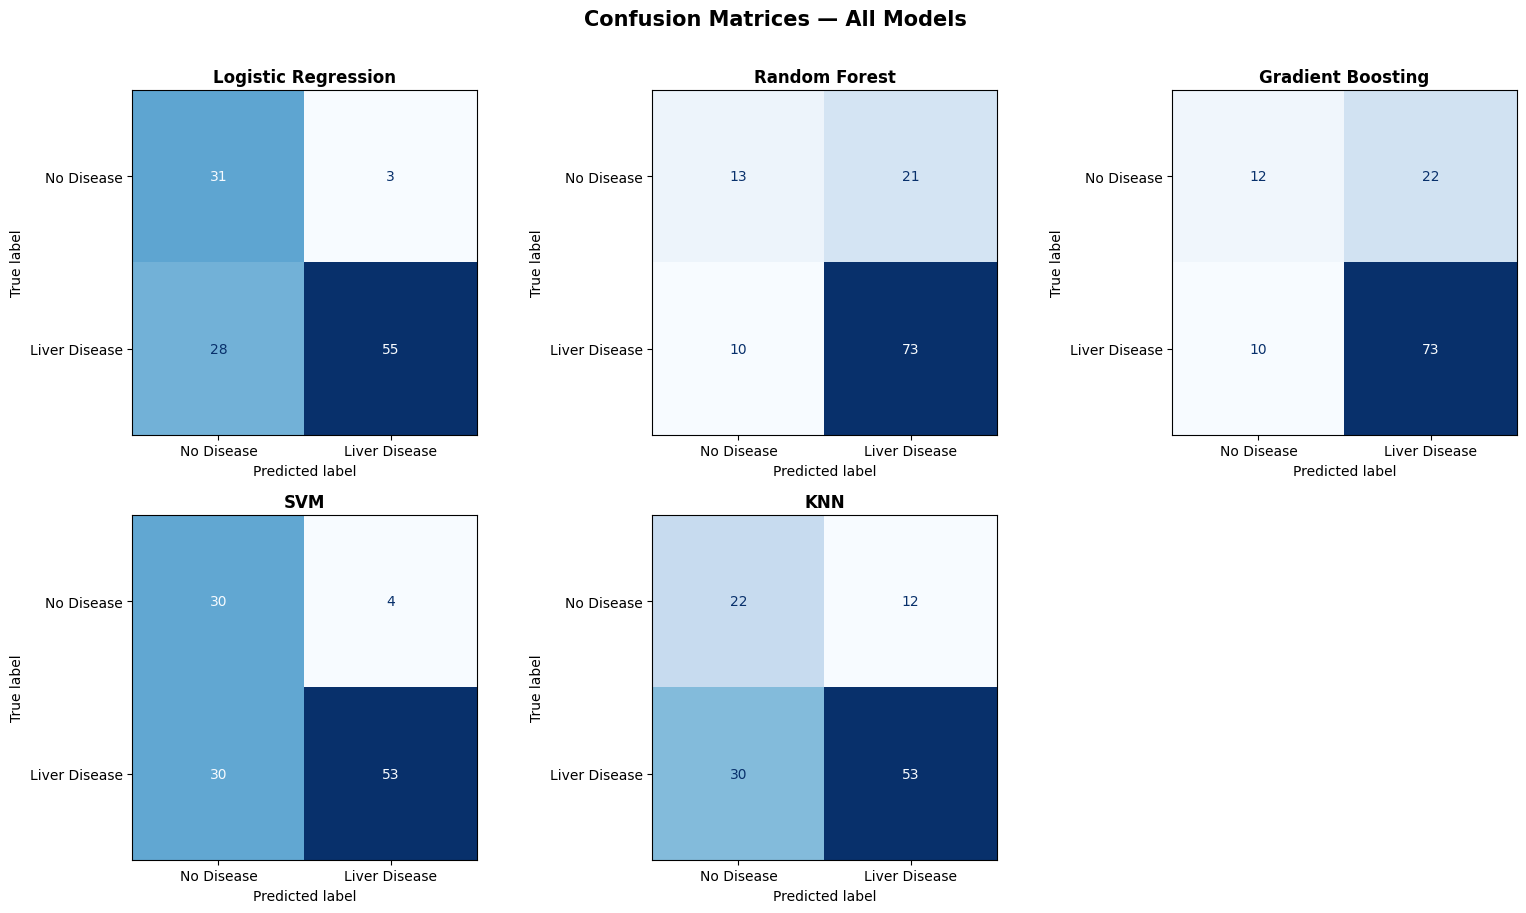

In [ ]:
n_models = len(trained_models)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_full_sc)
    cm = confusion_matrix(y_test_full, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Liver Disease'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontweight='bold')

# Hide unused subplot
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##  ROC Curves (All Models)

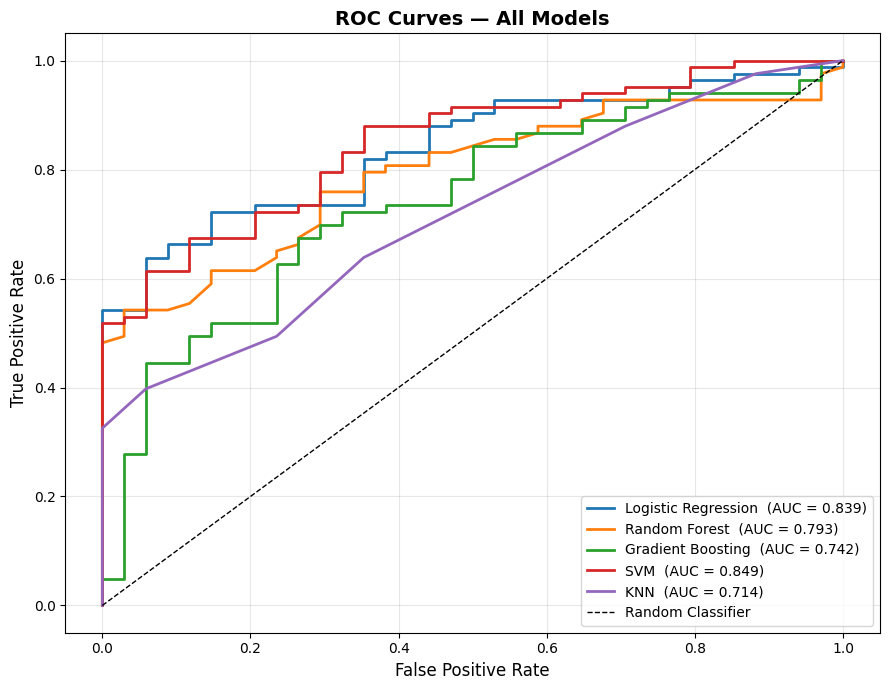

In [ ]:
plt.figure(figsize=(9, 7))

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_full_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_full, y_proba)
    auc_val = roc_auc_score(y_test_full, y_proba)
    plt.plot(fpr, tpr, lw=2, label=f'{name}  (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##  Feature Importance (Random Forest)

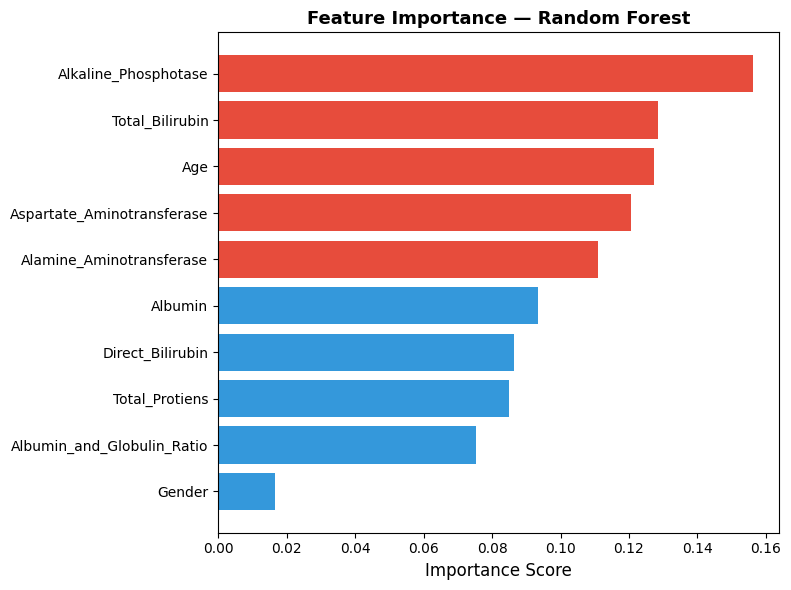


Top 5 most important features:
                      Feature  Importance
4        Alkaline_Phosphotase    0.156107
2             Total_Bilirubin    0.128378
0                         Age    0.127309
6  Aspartate_Aminotransferase    0.120725
5    Alamine_Aminotransferase    0.110884


In [ ]:
rf_model = trained_models['Random Forest']
importances = f_model.feature_importances_
feat_names  = X_full.columns

feat_imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
colors = ['#e74c3c' if v > 0.1 else '#3498db' for v in feat_imp_df['Importance']]
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(feat_imp_df.sort_values('Importance', ascending=False).head())

## Full vs Reduced Dataset Comparison

In [ ]:
# Compare best model (Random Forest) on both datasets
rf_full    = RandomForestClassifier(n_estimators=200, random_state=42)
rf_reduced = RandomForestClassifier(n_estimators=200, random_state=42)

rf_full.fit(X_train_full_sc, y_train_full)
rf_reduced.fit(X_train_reduced_sc, y_train_reduced)

acc_full    = accuracy_score(y_test_full,    rf_full.predict(X_test_full_sc))
acc_reduced = accuracy_score(y_test_reduced, rf_reduced.predict(X_test_reduced_sc))
auc_full    = roc_auc_score(y_test_full,    rf_full.predict_proba(X_test_full_sc)[:, 1])
auc_reduced = roc_auc_score(y_test_reduced, rf_reduced.predict_proba(X_test_reduced_sc)[:, 1])

comparison = pd.DataFrame({
    'Dataset'  : ['Full', 'Reduced'],
    'Features' : [X_full.shape[1], X_reduced.shape[1]],
    'Accuracy' : [round(acc_full, 4), round(acc_reduced, 4)],
    'ROC-AUC'  : [round(auc_full, 4), round(auc_reduced, 4)]
})

print('\n Full vs Reduced Dataset — Random Forest')
print(comparison.to_string(index=False))


 Full vs Reduced Dataset — Random Forest
Dataset  Features  Accuracy  ROC-AUC
   Full        10     0.735   0.7932
Reduced         9     0.735   0.7895


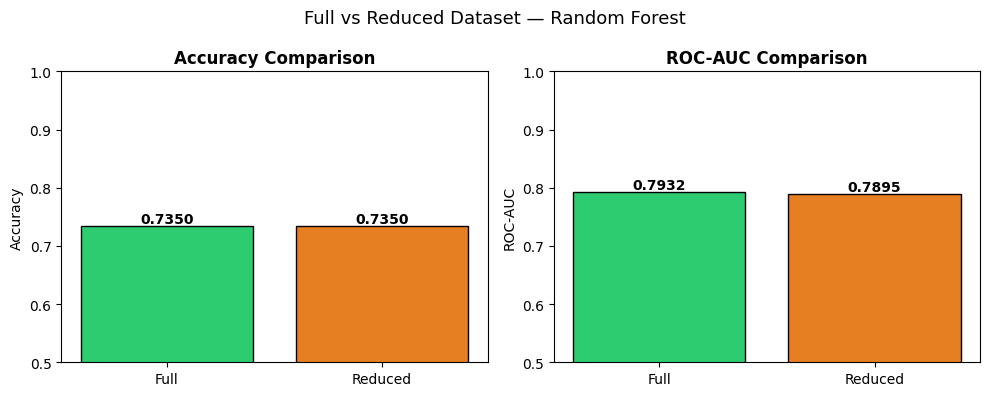

In [ ]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, metric in zip(axes, ['Accuracy', 'ROC-AUC']):
    ax.bar(['Full', 'Reduced'], comparison[metric], color=['#2ecc71', '#e67e22'], edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel(metric)
    for i, v in enumerate(comparison[metric]):
        ax.text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
plt.suptitle('Full vs Reduced Dataset — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
##  Save Best Model

In [ ]:
import joblib

best_model_name = results_df.iloc[0]['Model']
best_model      = trained_models[best_model_name]

joblib.dump(best_model,   'liver_best_model.pkl')
joblib.dump(scaler_full,  'liver_scaler.pkl')

print(f'  Best model : {best_model_name}')
print(f'   Accuracy  : {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'   ROC-AUC   : {results_df.iloc[0]["ROC-AUC"]:.4f}')
print('\n Saved → liver_best_model.pkl  |  liver_scaler.pkl')

  Best model : Logistic Regression
   Accuracy  : 0.7350
   ROC-AUC   : 0.8391

 Saved → liver_best_model.pkl  |  liver_scaler.pkl


## Quick Inference Test (Sample Prediction)

In [ ]:
# Test with one sample from test set
sample     = X_test_full.iloc[[0]]
actual     = y_test_full.iloc[0]

sample_sc  = scaler_full.transform(sample)
prediction = best_model.predict(sample_sc)[0]
confidence = best_model.predict_proba(sample_sc)[0]

label_map = {1: 'Liver Disease', 0: ' No Disease'}
print(' Sample Inference Test')
print(f'   Actual     : {label_map[actual]}')
print(f'   Predicted  : {label_map[prediction]}')
print(f'   Confidence : No Disease={confidence[0]:.3f}  |  Liver Disease={confidence[1]:.3f}')
print(f'   Result     : {"CORRECT" if prediction == actual else " WRONG"}')

 Sample Inference Test
   Actual     : Liver Disease
   Predicted  : Liver Disease
   Confidence : No Disease=0.432  |  Liver Disease=0.568
   Result     : CORRECT
